In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
df = pd.read_csv('Project_description_and_data/claims_train.csv')
df_test = pd.read_csv('Project_description_and_data/claims_test.csv')

# --------------------------------------------------
# BASIC FEATURE ENGINEERING
# --------------------------------------------------
def basic_feature_engineering(df):
    df = df.copy()
    
    df['Exposure_adj'] = df['Exposure'].clip(upper=1.0)
    df['VehAge_1'] = df['VehAge'] + 1
    df['VehAge_log'] = np.log(df['VehAge_1'])
    df['DrivAge_log'] = np.log(df['DrivAge'])
    df['Density_log'] = np.log(df['Density'])
    
    cat_cols = ['VehBrand', 'Area', 'Region', 'VehGas']
    for c in cat_cols:
        df[c] = df[c].astype('category')
        
    return df

# --------------------------------------------------
# TRAIN / VALIDATION SPLIT (ONCE!)
# --------------------------------------------------
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)

df_train = basic_feature_engineering(df_train)
df_val   = basic_feature_engineering(df_val)
df_test  = basic_feature_engineering(df_test)

# --------------------------------------------------
# PCA (FIT ON TRAIN ONLY)
# --------------------------------------------------
pca_features = [
    'DrivAge_log',
    'VehPower',
    'VehAge_log',
    'Density_log',
    'BonusMalus'
]

scaler_pca = StandardScaler()
X_pca_train = scaler_pca.fit_transform(df_train[pca_features])

pca = PCA(n_components=3, random_state=42)
X_pca_train = pca.fit_transform(X_pca_train)

for i in range(3):
    df_train[f'PC{i+1}'] = X_pca_train[:, i]

def apply_pca(df, scaler_pca, pca, pca_features):
    X_scaled = scaler_pca.transform(df[pca_features])
    X_pca = pca.transform(X_scaled)
    
    df = df.copy()
    for i in range(X_pca.shape[1]):
        df[f'PC{i+1}'] = X_pca[:, i]
    return df

df_val  = apply_pca(df_val, scaler_pca, pca, pca_features)
df_test = apply_pca(df_test, scaler_pca, pca, pca_features)

# --------------------------------------------------
# INTERACTION FEATURES (TRAIN + VAL)
# --------------------------------------------------
def add_interactions(df):
    df = df.copy()
    df['DrivAgeLog_BonusMalus'] = df['DrivAge_log'] * df['BonusMalus']
    df['VehPower_DensityLog']  = df['VehPower'] * df['Density_log']
    df['BonusMalus_Exposure']  = df['BonusMalus'] * df['Exposure_adj']
    return df

df_train = add_interactions(df_train)
df_val   = add_interactions(df_val)
df_test  = add_interactions(df_test)

# --------------------------------------------------
# FEATURE SET
# --------------------------------------------------
feature_cols = [
    'VehBrand',
    'Region',
    'PC1', 'PC2', 'PC3',
    'DrivAgeLog_BonusMalus',
    'VehPower_DensityLog',
    'BonusMalus_Exposure'
]

categorical_features = ['VehBrand', 'Region']
numerical_features = [c for c in feature_cols if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

preprocessor.set_output(transform="pandas")

X_train = preprocessor.fit_transform(df_train[feature_cols])
X_val   = preprocessor.transform(df_val[feature_cols])
X_test  = preprocessor.transform(df_test[feature_cols])

X_train.columns = [c.split("__")[-1] for c in X_train.columns]
X_val.columns   = X_train.columns
X_test.columns  = X_train.columns

# --------------------------------------------------
# SCALING (FIT ON TRAIN)
# --------------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

y_train = df_train['ClaimNb'].values.reshape(-1, 1)
y_val   = df_val['ClaimNb'].values.reshape(-1, 1)
y_test  = df_test['ClaimNb'].values.reshape(-1, 1)


def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

class FFNNRegressor:
    """Neural Network Regressor with L2 regularization and Dropout support"""
    
    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=0.01, 
                 l2_lambda=0.0, dropout_rate=0.0):
        
        self.lr = learning_rate
        self.l2_lambda = l2_lambda
        self.dropout_rate = dropout_rate
        
        # Initialize weights
        # NOTE: keep initialization the same (He initialization)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        
        # NOTE: Output dim is usually 1 for regression (predicting one value)
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        
    def forward(self, X, training=True):
        """Forward pass with optional dropout"""
        # Hidden layer
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)
        
        # Apply dropout during training
        if training and self.dropout_rate > 0:
            keep_prob = 1 - self.dropout_rate
            self.dropout_mask = np.random.binomial(1, keep_prob, size=self.a1.shape)
            self.a1 = self.a1 * self.dropout_mask / keep_prob
        
        # Output layer
        self.z2 = self.a1 @ self.W2 + self.b2
        
        # NOTE: CHANGE 1 - Linear Activation
        # Unlike classification (Softmax), we just return z2 directly.
        # This allows the network to predict any number (negative or positive).
        self.y_pred = self.z2 
        
        return self.y_pred
    
    def backward(self, X, y_true):
        """Backward pass with L2 regularization"""
        batch_size = X.shape[0]
        
        # NOTE: CHANGE 2 - Gradient Calculation
        # The derivative of MSE with respect to the output is simply (predicted - true).
        # Softmax derivative was complex; Linear + MSE derivative is simple.
        dz2 = self.y_pred - y_true
        
        self.dW2 = (self.a1.T @ dz2) / batch_size
        self.db2 = np.sum(dz2, axis=0, keepdims=True) / batch_size
        
        # Add L2 regularization gradient for W2
        if self.l2_lambda > 0:
            self.dW2 += self.l2_lambda * self.W2
        
        # Hidden layer gradients (Standard Backprop)
        da1 = dz2 @ self.W2.T
        
        # Apply dropout mask to gradient
        if self.dropout_rate > 0:
            keep_prob = 1 - self.dropout_rate
            da1 = da1 * self.dropout_mask / keep_prob
        
        dz1 = da1 * relu_derivative(self.z1)
        self.dW1 = (X.T @ dz1) / batch_size
        self.db1 = np.sum(dz1, axis=0, keepdims=True) / batch_size
        
        # Add L2 regularization gradient for W1
        if self.l2_lambda > 0:
            self.dW1 += self.l2_lambda * self.W1
        
    def update_weights(self):
        """Update weights using gradient descent"""
        self.W1 -= self.lr * self.dW1
        self.b1 -= self.lr * self.db1
        self.W2 -= self.lr * self.dW2
        self.b2 -= self.lr * self.db2
        
    def compute_loss(self, y_true, y_pred):
        """Compute MSE loss with optional L2 regularization"""
        batch_size = y_true.shape[0]
        
        # Instead of Cross-Entropy, we use MSE for regression.
        # Formula: (1/2) * mean((y_pred - y_true)^2)
        mse_loss = np.mean(0.5 * (y_pred - y_true)**2)
        
        # Add L2 regularization term
        if self.l2_lambda > 0:
            l2_loss = (self.l2_lambda / 2) * (np.sum(self.W1**2) + np.sum(self.W2**2))
            return mse_loss + l2_loss
        
        return mse_loss
    
    def predict(self, X):
        """Make predictions (no dropout)"""
        return self.forward(X, training=False)
    
    def evaluate_metric(self, X, y_true):
        """
        Compute R2 Score (coefficient of determination).
        Returns how well the regression predictions approximate the real data points.
        1.0 is perfect, 0.0 is baseline, negative is worse than baseline.
        """
        y_pred = self.predict(X)
        return r2_score(y_true, y_pred)
    
def train_model(model, X_train, y_train, X_val, y_val, num_epochs, verbose=False):
    """Train a model and return training history"""
    train_losses = []
    val_losses = []
    train_scores = []
    val_scores = []
    
    for epoch in range(num_epochs):
        # Training
        y_pred_train = model.forward(X_train, training=True)
        train_loss = model.compute_loss(y_train, y_pred_train)
        model.backward(X_train, y_train)
        model.update_weights()
        
        # Validation (no dropout)
        y_pred_val = model.forward(X_val, training=False)
        val_loss = model.compute_loss(y_val, y_pred_val)
        
        # NOTE: Metric changed from Accuracy to R2 Score
        train_score = model.evaluate_metric(X_train, y_train)
        val_score = model.evaluate_metric(X_val, y_val)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_scores.append(train_score)
        val_scores.append(val_score)
        
        if verbose and (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val R2: {val_score:.4f}")

    return train_losses, val_losses, train_scores, val_scores


lambda_values = [0.001, 0.01, 0.1]
l2_results = {}

print("\nTuning L2 regularization")

for lam in lambda_values:
    print(f"Training with L2 λ = {lam}")
    
    model = FFNNRegressor(
        input_dim=X_train.shape[1],
        hidden_dim=128,
        output_dim=1,
        learning_rate=0.01,
        l2_lambda=lam
    )
    
    _, _, _, val_scores = train_model(
        model,
        X_train, y_train,
        X_val, y_val,
        num_epochs=250
    )
    
    l2_results[lam] = val_scores[-1]
    print(f"  Final Val R2: {val_scores[-1]:.4f}")

dropout_rates = [0.0, 0.2, 0.4]
dropout_results = {}

print("\nTuning dropout")

for d in dropout_rates:
    print(f"Training with dropout = {d}")
    
    model = FFNNRegressor(
        input_dim=X_train.shape[1],
        hidden_dim=128,
        output_dim=1,
        learning_rate=0.01,
        dropout_rate=d
    )
    
    _, _, _, val_scores = train_model(
        model,
        X_train, y_train,
        X_val, y_val,
        num_epochs=250
    )
    
    dropout_results[d] = val_scores[-1]
    print(f"  Final Val R2: {val_scores[-1]:.4f}")

best_lambda = max(l2_results, key=l2_results.get)
best_dropout = max(dropout_results, key=dropout_results.get)

print("\nBest hyperparameters (from validation only)")
print(f"Best L2 λ: {best_lambda}")
print(f"Best dropout: {best_dropout}")

# Combine train and validation sets
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.vstack([y_train, y_val])

final_model = FFNNRegressor(
    input_dim=X_train.shape[1],
    hidden_dim=128,
    output_dim=1,
    learning_rate=0.01,
    l2_lambda=best_lambda,
    dropout_rate=best_dropout
)

print("\nTraining final model on train + validation data")

train_model(
    final_model,
    X_train_full, y_train_full,
    X_val, y_val,        # only used for monitoring
    num_epochs=300,
    verbose=True
)

print("\nFINAL TEST SET EVALUATION")

y_test_pred = final_model.predict(X_test)

test_mse = mean_squared_error(y_test, y_test_pred)
test_r2  = r2_score(y_test, y_test_pred)
test_mae=mean_absolute_error(y_test, y_test_pred)

print(f"Test MSE: {test_mse:.4f}")
print(f"Test MAE: {test_mae: .4f}")
print(f"Test R2:  {test_r2:.4f}")


Tuning L2 regularization
Training with L2 λ = 0.001
  Final Val R2: -0.8911
Training with L2 λ = 0.01
  Final Val R2: -1.0805
Training with L2 λ = 0.1
  Final Val R2: -0.4030

Tuning dropout
Training with dropout = 0.0
  Final Val R2: -1.2771
Training with dropout = 0.2
  Final Val R2: -0.3487
Training with dropout = 0.4
  Final Val R2: -0.0412

Best hyperparameters (from validation only)
Best L2 λ: 0.1
Best dropout: 0.4

Training final model on train + validation data
Epoch  50 | Train Loss: 11.8019 | Val Loss: 11.5972 | Val R2: -1.5518
Epoch 100 | Train Loss: 10.5370 | Val Loss: 10.4401 | Val R2: -0.3962
Epoch 150 | Train Loss: 9.4863 | Val Loss: 9.4314 | Val R2: -0.1464
Epoch 200 | Train Loss: 8.5641 | Val Loss: 8.5287 | Val R2: -0.0628
Epoch 250 | Train Loss: 7.7411 | Val Loss: 7.7157 | Val R2: -0.0282
Epoch 300 | Train Loss: 7.0015 | Val Loss: 6.9818 | Val R2: -0.0119

FINAL TEST SET EVALUATION
Test MSE: 0.0610
Test MAE:  0.1018
Test R2:  -0.0136


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------
df = pd.read_csv('Project_description_and_data/claims_train.csv')
df_test = pd.read_csv('Project_description_and_data/claims_test.csv')

# --------------------------------------------------
# BASIC FEATURE ENGINEERING
# --------------------------------------------------
def basic_feature_engineering(df):
    df = df.copy()
    
    df['Exposure_adj'] = df['Exposure'].clip(upper=1.0)
    df['VehAge_1'] = df['VehAge'] + 1
    df['VehAge_log'] = np.log(df['VehAge_1'])
    df['DrivAge_log'] = np.log(df['DrivAge'])
    df['Density_log'] = np.log(df['Density'])
    
    cat_cols = ['VehBrand', 'Area', 'Region', 'VehGas']
    for c in cat_cols:
        df[c] = df[c].astype('category')
        
    return df

# --------------------------------------------------
# TRAIN / VALIDATION SPLIT (ONCE!)
# --------------------------------------------------
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42)

df_train = basic_feature_engineering(df_train)
df_val   = basic_feature_engineering(df_val)
df_test  = basic_feature_engineering(df_test)

# --------------------------------------------------
# PCA (FIT ON TRAIN ONLY)
# --------------------------------------------------
pca_features = [
    'DrivAge_log',
    'VehPower',
    'VehAge_log',
    'Density_log',
    'BonusMalus'
]

scaler_pca = StandardScaler()
X_pca_train = scaler_pca.fit_transform(df_train[pca_features])

pca = PCA(n_components=3, random_state=42)
X_pca_train = pca.fit_transform(X_pca_train)

for i in range(3):
    df_train[f'PC{i+1}'] = X_pca_train[:, i]

def apply_pca(df, scaler_pca, pca, pca_features):
    X_scaled = scaler_pca.transform(df[pca_features])
    X_pca = pca.transform(X_scaled)
    
    df = df.copy()
    for i in range(X_pca.shape[1]):
        df[f'PC{i+1}'] = X_pca[:, i]
    return df

df_val  = apply_pca(df_val, scaler_pca, pca, pca_features)
df_test = apply_pca(df_test, scaler_pca, pca, pca_features)

# --------------------------------------------------
# INTERACTION FEATURES (TRAIN + VAL)
# --------------------------------------------------
def add_interactions(df):
    df = df.copy()
    df['DrivAgeLog_BonusMalus'] = df['DrivAge_log'] * df['BonusMalus']
    df['VehPower_DensityLog']  = df['VehPower'] * df['Density_log']
    df['BonusMalus_Exposure']  = df['BonusMalus'] * df['Exposure_adj']
    return df

df_train = add_interactions(df_train)
df_val   = add_interactions(df_val)
df_test  = add_interactions(df_test)

# --------------------------------------------------
# FEATURE SET
# --------------------------------------------------
feature_cols = [
    'VehBrand',
    'Region',
    'PC1', 'PC2', 'PC3',
    'DrivAgeLog_BonusMalus',
    'VehPower_DensityLog',
    'BonusMalus_Exposure'
]

categorical_features = ['VehBrand', 'Region']
numerical_features = [c for c in feature_cols if c not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

preprocessor.set_output(transform="pandas")

X_train = preprocessor.fit_transform(df_train[feature_cols])
X_val   = preprocessor.transform(df_val[feature_cols])
X_test  = preprocessor.transform(df_test[feature_cols])

X_train.columns = [c.split("__")[-1] for c in X_train.columns]
X_val.columns   = X_train.columns
X_test.columns  = X_train.columns

# --------------------------------------------------
# SCALING (FIT ON TRAIN)
# --------------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

y_train = df_train['ClaimNb'].values.reshape(-1, 1)
y_val   = df_val['ClaimNb'].values.reshape(-1, 1)
y_test  = df_test['ClaimNb'].values.reshape(-1, 1)

In [15]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

class FFNNRegressor:
    """Neural Network Regressor with L2 regularization and Dropout support"""
    
    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=0.01, 
                 l2_lambda=0.0, dropout_rate=0.0):
        
        self.lr = learning_rate
        self.l2_lambda = l2_lambda
        self.dropout_rate = dropout_rate
        
        # Initialize weights
        # NOTE: keep initialization the same (He initialization)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        
        # NOTE: Output dim is usually 1 for regression (predicting one value)
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        
    def forward(self, X, training=True):
        """Forward pass with optional dropout"""
        # Hidden layer
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)
        
        # Apply dropout during training
        if training and self.dropout_rate > 0:
            keep_prob = 1 - self.dropout_rate
            self.dropout_mask = np.random.binomial(1, keep_prob, size=self.a1.shape)
            self.a1 = self.a1 * self.dropout_mask / keep_prob
        
        # Output layer
        self.z2 = self.a1 @ self.W2 + self.b2
        
        # NOTE: CHANGE 1 - Linear Activation
        # Unlike classification (Softmax), we just return z2 directly.
        # This allows the network to predict any number (negative or positive).
        self.y_pred = self.z2 
        
        return self.y_pred
    
    def backward(self, X, y_true):
        """Backward pass with L2 regularization"""
        batch_size = X.shape[0]
        
        # NOTE: CHANGE 2 - Gradient Calculation
        # The derivative of MSE with respect to the output is simply (predicted - true).
        # Softmax derivative was complex; Linear + MSE derivative is simple.
        dz2 = self.y_pred - y_true
        
        self.dW2 = (self.a1.T @ dz2) / batch_size
        self.db2 = np.sum(dz2, axis=0, keepdims=True) / batch_size
        
        # Add L2 regularization gradient for W2
        if self.l2_lambda > 0:
            self.dW2 += self.l2_lambda * self.W2
        
        # Hidden layer gradients (Standard Backprop)
        da1 = dz2 @ self.W2.T
        
        # Apply dropout mask to gradient
        if self.dropout_rate > 0:
            keep_prob = 1 - self.dropout_rate
            da1 = da1 * self.dropout_mask / keep_prob
        
        dz1 = da1 * relu_derivative(self.z1)
        self.dW1 = (X.T @ dz1) / batch_size
        self.db1 = np.sum(dz1, axis=0, keepdims=True) / batch_size
        
        # Add L2 regularization gradient for W1
        if self.l2_lambda > 0:
            self.dW1 += self.l2_lambda * self.W1
        
    def update_weights(self):
        """Update weights using gradient descent"""
        self.W1 -= self.lr * self.dW1
        self.b1 -= self.lr * self.db1
        self.W2 -= self.lr * self.dW2
        self.b2 -= self.lr * self.db2
        
    def compute_loss(self, y_true, y_pred):
        """Compute MSE loss with optional L2 regularization"""
        batch_size = y_true.shape[0]
        
        # Instead of Cross-Entropy, we use MSE for regression.
        # Formula: (1/2) * mean((y_pred - y_true)^2)
        mse_loss = np.mean(0.5 * (y_pred - y_true)**2)
        
        # Add L2 regularization term
        if self.l2_lambda > 0:
            l2_loss = (self.l2_lambda / 2) * (np.sum(self.W1**2) + np.sum(self.W2**2))
            return mse_loss + l2_loss
        
        return mse_loss
    
    def predict(self, X):
        """Make predictions (no dropout)"""
        return self.forward(X, training=False)
    
    def evaluate_metric(self, X, y_true):
        """
        Compute R2 Score (coefficient of determination).
        Returns how well the regression predictions approximate the real data points.
        1.0 is perfect, 0.0 is baseline, negative is worse than baseline.
        """
        y_pred = self.predict(X)
        return r2_score(y_true, y_pred)

In [9]:
def train_model(model, X_train, y_train, X_val, y_val, num_epochs, verbose=False):
    """Train a model and return training history"""
    train_losses = []
    val_losses = []
    train_scores = []
    val_scores = []
    
    for epoch in range(num_epochs):
        # Training
        y_pred_train = model.forward(X_train, training=True)
        train_loss = model.compute_loss(y_train, y_pred_train)
        model.backward(X_train, y_train)
        model.update_weights()
        
        # Validation (no dropout)
        y_pred_val = model.forward(X_val, training=False)
        val_loss = model.compute_loss(y_val, y_pred_val)
        
        # NOTE: Metric changed from Accuracy to R2 Score
        train_score = model.evaluate_metric(X_train, y_train)
        val_score = model.evaluate_metric(X_val, y_val)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_scores.append(train_score)
        val_scores.append(val_score)
        
        if verbose and (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val R2: {val_score:.4f}")

    return train_losses, val_losses, train_scores, val_scores


# -----------------------------
# MANUAL MODEL (NO TUNING)
# -----------------------------
model_manual = FFNNRegressor(
    input_dim=X_train.shape[1],
    hidden_dim=128,
    output_dim=1,
    learning_rate=0.005,
    l2_lambda=0.01,
    dropout_rate=0.2
)

train_losses, val_losses, train_scores, val_scores = train_model(
    model_manual,
    X_train, y_train,
    X_val, y_val,
    num_epochs=250,
    verbose=True
)

print(f"Final Validation R2: {val_scores[-1]:.4f}")


Epoch  50 | Train Loss: 1.6506 | Val Loss: 1.4874 | Val R2: -6.2379
Epoch 100 | Train Loss: 1.5071 | Val Loss: 1.3806 | Val R2: -2.8480
Epoch 150 | Train Loss: 1.4436 | Val Loss: 1.3411 | Val R2: -1.7612
Epoch 200 | Train Loss: 1.4043 | Val Loss: 1.3187 | Val R2: -1.2494
Epoch 250 | Train Loss: 1.3741 | Val Loss: 1.3027 | Val R2: -0.9495
Final Validation R2: -0.9495


In [ ]:
lambda_values = [0.001, 0.01, 0.1]
l2_results = {}

print("\nTuning L2 regularization")

for lam in lambda_values:
    print(f"Training with L2 λ = {lam}")
    
    model = FFNNRegressor(
        input_dim=X_train.shape[1],
        hidden_dim=128,
        output_dim=1,
        learning_rate=0.01,
        l2_lambda=lam
    )
    
    _, _, _, val_scores = train_model(
        model,
        X_train, y_train,
        X_val, y_val,
        num_epochs=250
    )
    
    l2_results[lam] = val_scores[-1]
    print(f"  Final Val R2: {val_scores[-1]:.4f}")

dropout_rates = [0.0, 0.2, 0.4]
dropout_results = {}

print("\nTuning dropout")

for d in dropout_rates:
    print(f"Training with dropout = {d}")
    
    model = FFNNRegressor(
        input_dim=X_train.shape[1],
        hidden_dim=128,
        output_dim=1,
        learning_rate=0.01,
        dropout_rate=d
    )
    
    _, _, _, val_scores = train_model(
        model,
        X_train, y_train,
        X_val, y_val,
        num_epochs=250
    )
    
    dropout_results[d] = val_scores[-1]
    print(f"  Final Val R2: {val_scores[-1]:.4f}")

best_lambda = max(l2_results, key=l2_results.get)
best_dropout = max(dropout_results, key=dropout_results.get)

print("\nBest hyperparameters (from validation only)")
print(f"Best L2 λ: {best_lambda}")
print(f"Best dropout: {best_dropout}")

# Combine train and validation sets
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.vstack([y_train, y_val])

final_model = FFNNRegressor(
    input_dim=X_train.shape[1],
    hidden_dim=128,
    output_dim=1,
    learning_rate=0.01,
    l2_lambda=best_lambda,
    dropout_rate=best_dropout
)

print("\nTraining final model on train + validation data")

train_model(
    final_model,
    X_train_full, y_train_full,
    X_val, y_val,        # only used for monitoring
    num_epochs=300,
    verbose=True
)

print("\nFINAL TEST SET EVALUATION")

y_test_pred = final_model.predict(X_test)

test_mse = mean_squared_error(y_test, y_test_pred)
test_r2  = r2_score(y_test, y_test_pred)
test_mae=mean_absolute_error(y_test, y_test_pred)

print(f"Test MSE: {test_mse:.4f}")
print(f"Test MAE: {test_mae: .4f}")
print(f"Test R2:  {test_r2:.4f}")


Tuning L2 regularization
Training with L2 λ = 0.001
  Final Val R2: -1.1463
Training with L2 λ = 0.01
  Final Val R2: -1.1329
Training with L2 λ = 0.1
  Final Val R2: -0.5112

Tuning dropout
Training with dropout = 0.0
  Final Val R2: -1.4068
Training with dropout = 0.2
  Final Val R2: -0.2818
Training with dropout = 0.4
  Final Val R2: -0.0472

Best hyperparameters (from validation only)
Best L2 λ: 0.1
Best dropout: 0.4

Training final model on train + validation data
Epoch  50 | Train Loss: 11.9717 | Val Loss: 11.7233 | Val R2: -1.4680
Epoch 100 | Train Loss: 10.6669 | Val Loss: 10.5526 | Val R2: -0.4545
Epoch 150 | Train Loss: 9.5926 | Val Loss: 9.5303 | Val R2: -0.1889
Epoch 200 | Train Loss: 8.6557 | Val Loss: 8.6165 | Val R2: -0.0859
Epoch 250 | Train Loss: 7.8214 | Val Loss: 7.7943 | Val R2: -0.0397
Epoch 300 | Train Loss: 7.0731 | Val Loss: 7.0525 | Val R2: -0.0171

FINAL TEST SET EVALUATION
Test MSE: 0.0612
Test R2:  -0.0161



Creating a Scenario
Epoch  50 | Train Loss: 0.1448 | Val Loss: 0.1432 | Val R2: -3.9639
Epoch 100 | Train Loss: 0.0917 | Val Loss: 0.0916 | Val R2: -2.1738
Epoch 150 | Train Loss: 0.0761 | Val Loss: 0.0762 | Val R2: -1.6415
Epoch 200 | Train Loss: 0.0679 | Val Loss: 0.0680 | Val R2: -1.3576
Epoch 250 | Train Loss: 0.0622 | Val Loss: 0.0624 | Val R2: -1.1608
Epoch 300 | Train Loss: 0.0578 | Val Loss: 0.0580 | Val R2: -1.0092


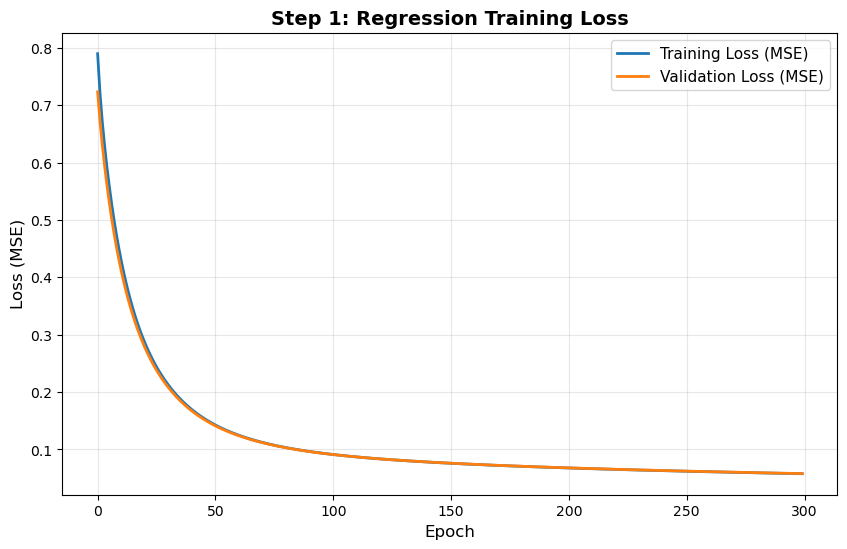


Applying L2 Weight Decay

Training with λ = 0.001
  Final Val R2: -0.9611

Training with λ = 0.01
  Final Val R2: -1.0363

Training with λ = 0.1
  Final Val R2: -0.3933


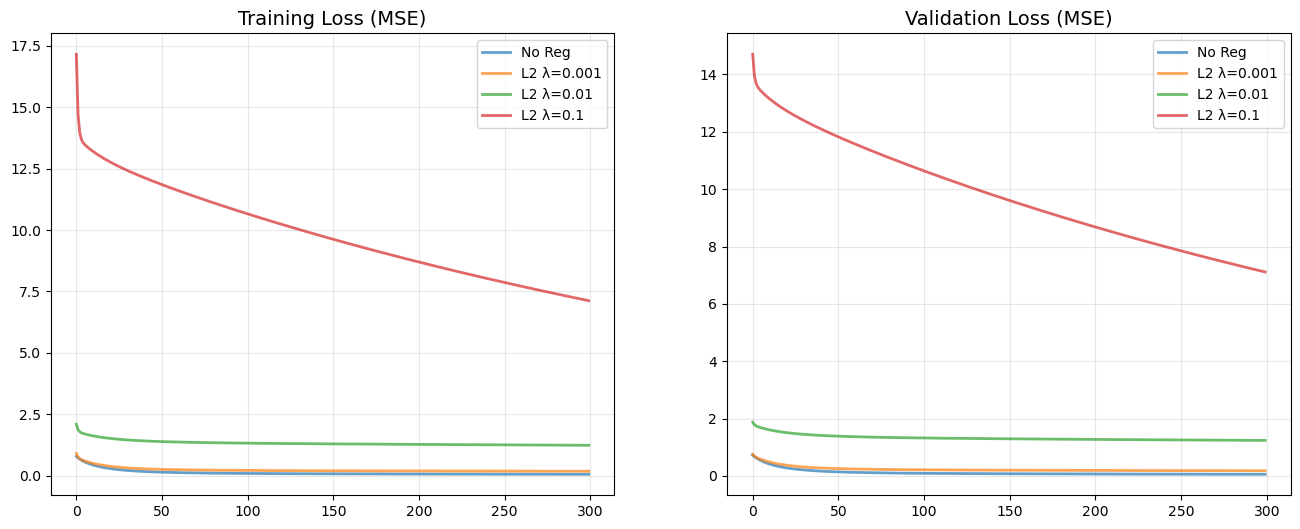


Applying Dropout

Training with dropout rate = 0.5 (keep p = 0.5)
  Final Val R2: 0.0142

Training with dropout rate = 0.30000000000000004 (keep p = 0.7)
  Final Val R2: -0.1000

Training with dropout rate = 0.09999999999999998 (keep p = 0.9)
  Final Val R2: -0.6144

Comparing All Methods
Best L2 lambda: 0.1
Best dropout keep probability: 0.5


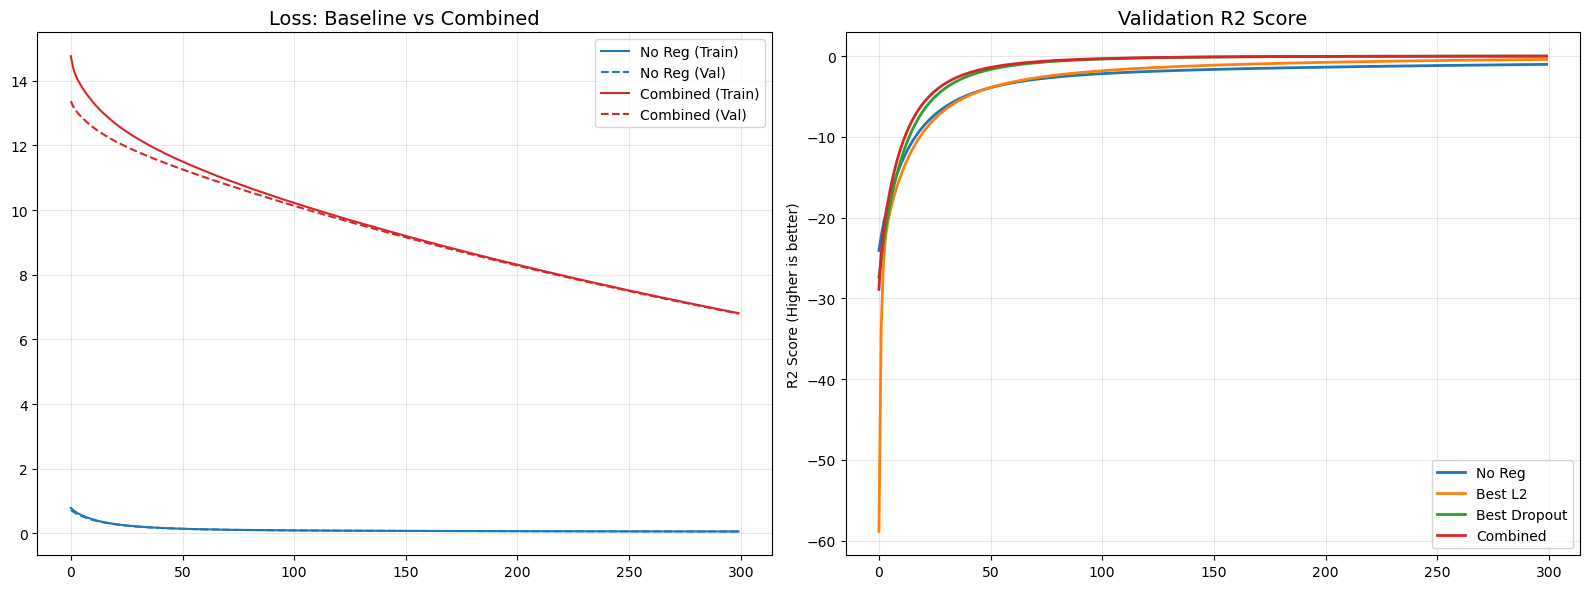


ANALYSIS SUMMARY

Method                    Final Val R2    Train-Val Loss Gap  
----------------------------------------------------------------------
No Regularization         -1.0092         -0.0002             
L2 (λ=0.1)                -0.3933         0.0139              
Dropout (p=0.5)           0.0142          0.0016              
L2 + Dropout              0.0124          0.0155              


In [ ]:
# Activation functions

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

# NOTE: removed Softmax.
# For regression, the output layer usually has "Linear" activation.
# This means f(x) = x. The derivative is just 1.

# --- CLASS DEFINITION ---

class FFNNRegressor:
    """Neural Network Regressor with L2 regularization and Dropout support"""
    
    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=0.01, 
                 l2_lambda=0.0, dropout_rate=0.0):
        
        self.lr = learning_rate
        self.l2_lambda = l2_lambda
        self.dropout_rate = dropout_rate
        
        # Initialize weights
        # NOTE: keep initialization the same (He initialization)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        
        # NOTE: Output dim is usually 1 for regression (predicting one value)
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        
    def forward(self, X, training=True):
        """Forward pass with optional dropout"""
        # Hidden layer
        self.z1 = X @ self.W1 + self.b1
        self.a1 = relu(self.z1)
        
        # Apply dropout during training
        if training and self.dropout_rate > 0:
            keep_prob = 1 - self.dropout_rate
            self.dropout_mask = np.random.binomial(1, keep_prob, size=self.a1.shape)
            self.a1 = self.a1 * self.dropout_mask / keep_prob
        
        # Output layer
        self.z2 = self.a1 @ self.W2 + self.b2
        
        # NOTE: CHANGE 1 - Linear Activation
        # Unlike classification (Softmax), we just return z2 directly.
        # This allows the network to predict any number (negative or positive).
        self.y_pred = self.z2 
        
        return self.y_pred
    
    def backward(self, X, y_true):
        """Backward pass with L2 regularization"""
        batch_size = X.shape[0]
        
        # NOTE: CHANGE 2 - Gradient Calculation
        # The derivative of MSE with respect to the output is simply (predicted - true).
        # Softmax derivative was complex; Linear + MSE derivative is simple.
        dz2 = self.y_pred - y_true
        
        self.dW2 = (self.a1.T @ dz2) / batch_size
        self.db2 = np.sum(dz2, axis=0, keepdims=True) / batch_size
        
        # Add L2 regularization gradient for W2
        if self.l2_lambda > 0:
            self.dW2 += self.l2_lambda * self.W2
        
        # Hidden layer gradients (Standard Backprop)
        da1 = dz2 @ self.W2.T
        
        # Apply dropout mask to gradient
        if self.dropout_rate > 0:
            keep_prob = 1 - self.dropout_rate
            da1 = da1 * self.dropout_mask / keep_prob
        
        dz1 = da1 * relu_derivative(self.z1)
        self.dW1 = (X.T @ dz1) / batch_size
        self.db1 = np.sum(dz1, axis=0, keepdims=True) / batch_size
        
        # Add L2 regularization gradient for W1
        if self.l2_lambda > 0:
            self.dW1 += self.l2_lambda * self.W1
        
    def update_weights(self):
        """Update weights using gradient descent"""
        self.W1 -= self.lr * self.dW1
        self.b1 -= self.lr * self.db1
        self.W2 -= self.lr * self.dW2
        self.b2 -= self.lr * self.db2
        
    def compute_loss(self, y_true, y_pred):
        """Compute MSE loss with optional L2 regularization"""
        batch_size = y_true.shape[0]
        
        # NOTE: CHANGE 3 - Mean Squared Error (MSE)
        # Instead of Cross-Entropy, we use MSE for regression.
        # Formula: (1/2) * mean((y_pred - y_true)^2)
        mse_loss = np.mean(0.5 * (y_pred - y_true)**2)
        
        # Add L2 regularization term
        if self.l2_lambda > 0:
            l2_loss = (self.l2_lambda / 2) * (np.sum(self.W1**2) + np.sum(self.W2**2))
            return mse_loss + l2_loss
        
        return mse_loss
    
    def predict(self, X):
        """Make predictions (no dropout)"""
        return self.forward(X, training=False)
    
    def evaluate_metric(self, X, y_true):
        """
        Compute R2 Score (coefficient of determination).
        Returns how well the regression predictions approximate the real data points.
        1.0 is perfect, 0.0 is baseline, negative is worse than baseline.
        """
        y_pred = self.predict(X)
        # Using sklearn here as requested for evaluation matrix
        return r2_score(y_true, y_pred)

# --- TRAINING LOOP ---

def train_model(model, X_train, y_train, X_val, y_val, num_epochs, verbose=False):
    """Train a model and return training history"""
    train_losses = []
    val_losses = []
    train_scores = [] # Changed 'accs' to 'scores' (R2)
    val_scores = []
    
    for epoch in range(num_epochs):
        # Training
        y_pred_train = model.forward(X_train, training=True)
        train_loss = model.compute_loss(y_train, y_pred_train)
        model.backward(X_train, y_train)
        model.update_weights()
        
        # Validation (no dropout)
        y_pred_val = model.forward(X_val, training=False)
        val_loss = model.compute_loss(y_val, y_pred_val)
        
        # NOTE: Metric changed from Accuracy to R2 Score
        train_score = model.evaluate_metric(X_train, y_train)
        val_score = model.evaluate_metric(X_val, y_val)
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_scores.append(train_score)
        val_scores.append(val_score)
        
        if verbose and (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val R2: {val_score:.4f}")

    return train_losses, val_losses, train_scores, val_scores

# --- EXECUTION & PLOTTING ---

# 1. Create an Overfitting Scenario
print("\nCreating a Scenario")

model_baseline = FFNNRegressor(
    input_dim=X_train.shape[1],
    hidden_dim=128,
    output_dim=1, # Regression usually has 1 output
    learning_rate=0.01 # Slightly lower LR often better for regression
)

train_losses_base, val_losses_base, train_scores_base, val_scores_base = train_model(
    model_baseline, X_train, y_train, X_val, y_val, num_epochs=300, verbose=True
)

# Plotting Step 1
plt.figure(figsize=(10, 6))
plt.plot(train_losses_base, label='Training Loss (MSE)', linewidth=2)
plt.plot(val_losses_base, label='Validation Loss (MSE)', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Step 1: Regression Training Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# 2. Apply L2 Weight Decay
print("\nApplying L2 Weight Decay")

lambda_values = [0.001, 0.01, 0.1]
l2_results = {}

for lam in lambda_values:
    print(f"\nTraining with λ = {lam}")
    model_l2 = FFNNRegressor(
        input_dim=X_train.shape[1],
        hidden_dim=128,
        output_dim=1,
        learning_rate=0.01,
        l2_lambda=lam
    )
    
    t_loss, v_loss, t_score, v_score = train_model(
        model_l2, X_train, y_train, X_val, y_val, num_epochs=300
    )
    
    l2_results[lam] = {
        'train_losses': t_loss, 'val_losses': v_loss,
        'train_scores': t_score, 'val_scores': v_score
    }
    
    print(f"  Final Val R2: {v_score[-1]:.4f}")

# Plot L2 results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(train_losses_base, label='No Reg', linewidth=2, alpha=0.7)
for lam, results in l2_results.items():
    axes[0].plot(results['train_losses'], label=f'L2 λ={lam}', linewidth=2, alpha=0.7)
axes[0].set_title('Training Loss (MSE)', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_losses_base, label='No Reg', linewidth=2, alpha=0.7)
for lam, results in l2_results.items():
    axes[1].plot(results['val_losses'], label=f'L2 λ={lam}', linewidth=2, alpha=0.7)
axes[1].set_title('Validation Loss (MSE)', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.show()

# 3. Apply Dropout
print("\nApplying Dropout")

dropout_rates = [0.5, 0.7, 0.9] # Probability of KEEPING
dropout_results = {}

for p in dropout_rates:
    dropout_prob = 1 - p
    print(f"\nTraining with dropout rate = {dropout_prob} (keep p = {p})")
    
    model_dropout = FFNNRegressor(
        input_dim=X_train.shape[1],
        hidden_dim=128,
        output_dim=1,
        learning_rate=0.01,
        dropout_rate=dropout_prob
    )
    
    t_loss, v_loss, t_score, v_score = train_model(
        model_dropout, X_train, y_train, X_val, y_val, num_epochs=300
    )
    
    dropout_results[p] = {
        'train_losses': t_loss, 'val_losses': v_loss,
        'train_scores': t_score, 'val_scores': v_score
    }
    print(f"  Final Val R2: {v_score[-1]:.4f}")

# 4. Compare All Methods
print("\nComparing All Methods")

# Find best hyperparameters based on R2 score (higher is better)
best_lambda = max(l2_results.keys(), key=lambda k: l2_results[k]['val_scores'][-1])
best_dropout = max(dropout_results.keys(), key=lambda k: dropout_results[k]['val_scores'][-1])

print(f"Best L2 lambda: {best_lambda}")
print(f"Best dropout keep probability: {best_dropout}")

# Train combined model
model_combined = FFNNRegressor(
    input_dim=X_train.shape[1],
    hidden_dim=128,
    output_dim=1,
    learning_rate=0.01,
    l2_lambda=best_lambda,
    dropout_rate=1-best_dropout
)

train_losses_comb, val_losses_comb, train_scores_comb, val_scores_comb = train_model(
    model_combined, X_train, y_train, X_val, y_val, num_epochs=300
)

# Final comparison plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training vs Validation Loss
axes[0].plot(train_losses_base, label='No Reg (Train)', linestyle='-', color='C0')
axes[0].plot(val_losses_base, label='No Reg (Val)', linestyle='--', color='C0')
axes[0].plot(train_losses_comb, label='Combined (Train)', linestyle='-', color='C3')
axes[0].plot(val_losses_comb, label='Combined (Val)', linestyle='--', color='C3')
axes[0].set_title('Loss: Baseline vs Combined', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation R2 Score
axes[1].plot(val_scores_base, label='No Reg', linewidth=2)
axes[1].plot(l2_results[best_lambda]['val_scores'], label=f'Best L2', linewidth=2)
axes[1].plot(dropout_results[best_dropout]['val_scores'], label=f'Best Dropout', linewidth=2)
axes[1].plot(val_scores_comb, label='Combined', linewidth=2)
axes[1].set_ylabel('R2 Score (Higher is better)')
axes[1].set_title('Validation R2 Score', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nANALYSIS SUMMARY")

methods = {
    'No Regularization': (train_losses_base, val_losses_base, val_scores_base),
    f'L2 (λ={best_lambda})': (l2_results[best_lambda]['train_losses'], l2_results[best_lambda]['val_losses'], l2_results[best_lambda]['val_scores']),
    f'Dropout (p={best_dropout})': (dropout_results[best_dropout]['train_losses'], dropout_results[best_dropout]['val_losses'], dropout_results[best_dropout]['val_scores']),
    'L2 + Dropout': (train_losses_comb, val_losses_comb, val_scores_comb)
}

print(f"\n{'Method':<25} {'Final Val R2':<15} {'Train-Val Loss Gap':<20}")
print("-" * 70)

for method, (train_l, val_l, val_s) in methods.items():
    final_score = val_s[-1]
    # Gap is strictly difference in loss here
    gap = train_l[-1] - val_l[-1] 
    print(f"{method:<25} {final_score:<15.4f} {gap:<20.4f}")